# Practical Statistics for Data Scientists - Chapter 4
## Regression and Prediction

This notebook covers simple linear regression, multiple linear regression, model evaluation metrics ($R^2$, RMSE), cross-validation, regression diagnostics (outliers, leverage, heteroskedasticity, multicollinearity), polynomial regression, and splines.

### Environment Setup and Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold


%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## 1. Simple Linear Regression

Modeling the relationship between a single predictor ($X$) and a continuous target ($Y$) using Ordinary Least Squares (OLS).

                            OLS Regression Results                            
Dep. Variable:                   PEFR   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     9.974
Date:                Mon, 28 Sep 2026   Prob (F-statistic):            0.00201
Time:                        06:42:27   Log-Likelihood:                -735.68
No. Observations:                 122   AIC:                             1475.
Df Residuals:                     120   BIC:                             1481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    424.5828     20.796     20.417      0.0

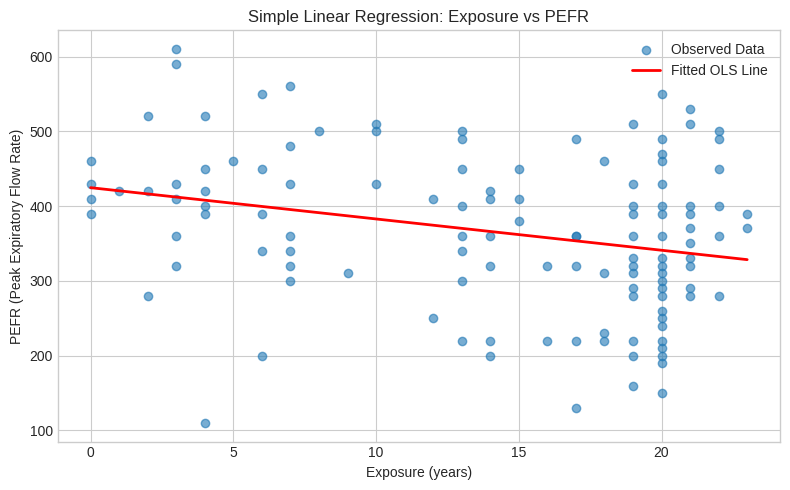

In [4]:
lung = pd.read_csv('drive/MyDrive/Colab Notebooks/data/LungDisease.csv')

model_simple = smf.ols('PEFR ~ Exposure', data=lung).fit()
print(model_simple.summary())

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(lung['Exposure'], lung['PEFR'], alpha=0.6, label='Observed Data')
ax.plot(lung['Exposure'], model_simple.fittedvalues, color='red', lw=2, label='Fitted OLS Line')
ax.set_xlabel('Exposure (years)')
ax.set_ylabel('PEFR (Peak Expiratory Flow Rate)')
ax.set_title('Simple Linear Regression: Exposure vs PEFR')
ax.legend()
plt.tight_layout()
plt.show()

---

## 2. Multiple Linear Regression & Model Evaluation

Extending regression to multiple predictor variables and evaluating performance using $R^2$, Adjusted $R^2$, and Root Mean Squared Error (RMSE).

In [5]:
house = pd.read_csv('drive/MyDrive/Colab Notebooks/data/house_sales.csv', sep='\t')

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = smf.ols(f'{outcome} ~ ' + ' + '.join(predictors), data=house).fit()
print(house_lm.summary())

rmse = np.sqrt(house_lm.mse_resid)
r2 = house_lm.rsquared
adj_r2 = house_lm.rsquared_adj

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²):               {r2:.4f}")
print(f"Adjusted R-squared:          {adj_r2:.4f}")

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:42:33   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -5.219e+05   1.57e+04    -33.342

---

## 3. Cross-Validation & Model Selection

Using K-Fold Cross-Validation to evaluate out-of-sample generalization error and avoid overfitting.

In [6]:
X = house[predictors]
y = house[outcome]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(LinearRegression(), X, y, scoring='neg_root_mean_squared_error', cv=kf)

print(f"5-Fold CV Mean RMSE: ${-scores.mean():,.2f} (+/- ${scores.std():,.2f})")

5-Fold CV Mean RMSE: $260,701.93 (+/- $20,587.13)


---

## 4. Regression Diagnostics

Checking model assumptions: **Heteroskedasticity**, **Outliers & High Leverage Points**, and **Multicollinearity (VIF)**.

### 4.1 Heteroskedasticity Check: Fitted Values vs Residuals

A key assumption in linear regression is homoskedasticity, meaning the variance of the errors is constant across all levels of the independent variables. We can visually inspect this by plotting fitted values against residuals. A random scatter suggests homoskedasticity, while a fanning or funnel shape indicates heteroskedasticity.

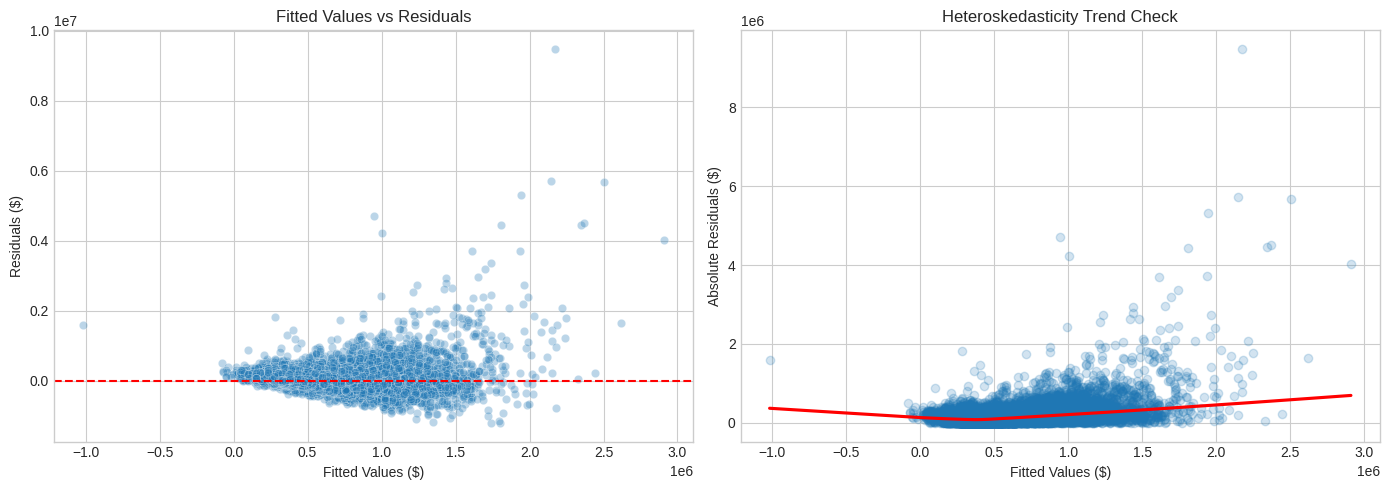

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitted vs Residual Plot
sns.scatterplot(x=house_lm.fittedvalues, y=house_lm.resid, ax=axes[0], alpha=0.3)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Fitted Values vs Residuals')

# Heteroskedasticity Assessment (Absolute Residuals vs Fitted)
sns.regplot(x=house_lm.fittedvalues, y=np.abs(house_lm.resid), scatter_kws={'alpha': 0.2},
            line_kws={'color': 'red'}, lowess=True, ax=axes[1])
axes[1].set_xlabel('Fitted Values ($)')
axes[1].set_ylabel('Absolute Residuals ($)')
axes[1].set_title('Heteroskedasticity Trend Check')

plt.tight_layout()
plt.show()

### 4.2 Multicollinearity Check: Variance Inflation Factor (VIF)

Multicollinearity occurs when predictor variables are highly correlated with each other. This can make it difficult to interpret the individual coefficients of the predictors. The Variance Inflation Factor (VIF) quantifies the severity of multicollinearity in an OLS regression. A VIF value greater than 5 or 10 is often considered problematic.

In [8]:
X_vif = sm.add_constant(X)
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print("Variance Inflation Factor (VIF):")
print(vif_data[vif_data['Feature'] != 'const'])

Variance Inflation Factor (VIF):
         Feature       VIF
1  SqFtTotLiving  4.218067
2        SqFtLot  1.047567
3      Bathrooms  2.576864
4       Bedrooms  1.685140
5      BldgGrade  2.659926


---

## 5. Polynomial Regression and Splines

Modeling non-linear relationships using higher-degree polynomial terms and piecewise splines.

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                 1.368e+04
Date:                Mon, 28 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:43:38   Log-Likelihood:            -3.1502e+05
No. Observations:               22687   AIC:                         6.300e+05
Df Residuals:                   22684   BIC:                         6.301e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              3.159e+

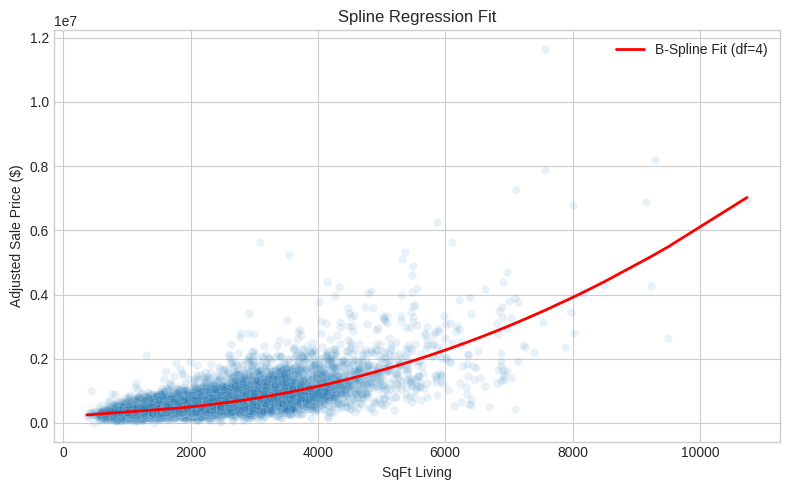

In [9]:
# Fitting Quadratic Polynomial Regression
poly_lm = smf.ols('AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving**2)', data=house).fit()
print(poly_lm.summary())

# Spline Regression using Generalized Additive Model (GAM) / Statsmodels Splines
spline_lm = smf.ols('AdjSalePrice ~ bs(SqFtTotLiving, df=4)', data=house).fit()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='SqFtTotLiving', y='AdjSalePrice', data=house, alpha=0.1, ax=ax)
sorted_x = house.sort_values('SqFtTotLiving')
ax.plot(sorted_x['SqFtTotLiving'], spline_lm.predict(sorted_x), color='red', lw=2, label='B-Spline Fit (df=4)')
ax.set_xlabel('SqFt Living')
ax.set_ylabel('Adjusted Sale Price ($)')
ax.set_title('Spline Regression Fit')
ax.legend()
plt.tight_layout()
plt.show()